# AMPHAN -- Aqua/MODIS true color, landfall (2020-05-20)

Built interactively: at each step, options were discussed and a choice was made before running it.

**Decisions so far:**
- Denoising: bilateral filter, medium strength
- No-data corners (black swath edges): masked out of all analysis

In [1]:
import cv2, numpy as np, math, json, csv, os
import matplotlib.pyplot as plt
%matplotlib inline

def show(img_bgr, title, figsize=(9,9)):
    plt.figure(figsize=figsize)
    if img_bgr.ndim == 2:
        plt.imshow(img_bgr, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

## Step 0 -- Load & inspect

Storm: AMPHAN | Aqua MODIS | 2020-05-20T07:30:00Z
Original resolution: (7789, 8103) -> working resolution: (1345, 1400)
No-data corner pixels: 137146 (7.3% of frame)


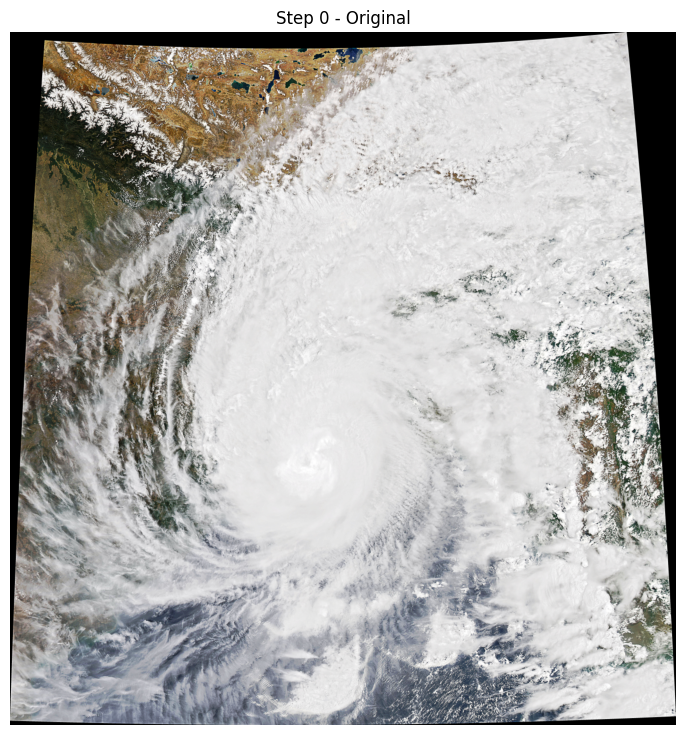

In [2]:
# ---- Step 0: Load & inspect ----
IMAGE_PATH = "../../../cyclone_images/AMPHAN/AMPHAN_aqua_modis_2020-05-20_landfall.jpg"
META_PATH  = "../../../cyclone_images/AMPHAN/AMPHAN_aqua_modis_2020-05-20_landfall.json"

with open(META_PATH) as f:
    meta = json.load(f)

img_bgr = cv2.imread(IMAGE_PATH, cv2.IMREAD_COLOR)
assert img_bgr is not None, f"Could not read image: {IMAGE_PATH}"
h0, w0 = img_bgr.shape[:2]

MAX_DIM = 1400
scale = min(1.0, MAX_DIM / max(h0, w0))
if scale < 1.0:
    img_bgr = cv2.resize(img_bgr, (int(w0*scale), int(h0*scale)), interpolation=cv2.INTER_AREA)
h, w = img_bgr.shape[:2]

print("Storm:", meta.get("storm_name"), "|", meta.get("satellite"), meta.get("sensor"), "|", meta.get("image_datetime_utc"))
print("Original resolution:", (w0, h0), "-> working resolution:", (w, h))

no_data_mask = (np.max(img_bgr, axis=2) < 12).astype(np.uint8) * 255
no_data_mask = cv2.morphologyEx(no_data_mask, cv2.MORPH_CLOSE, np.ones((7,7), np.uint8))
valid_mask = cv2.bitwise_not(no_data_mask)
print(f"No-data corner pixels: {(no_data_mask>0).sum()} ({100*(no_data_mask>0).sum()/(h*w):.1f}% of frame)")

show(img_bgr, "Step 0 - Original")

## Step 1 -- Preprocessing (denoise + no-data handling)

**Decision: bilateral filter, strong strength** (upgraded from medium per review).

Pixel-value std (valid area only) before: 54.95, after: 52.90


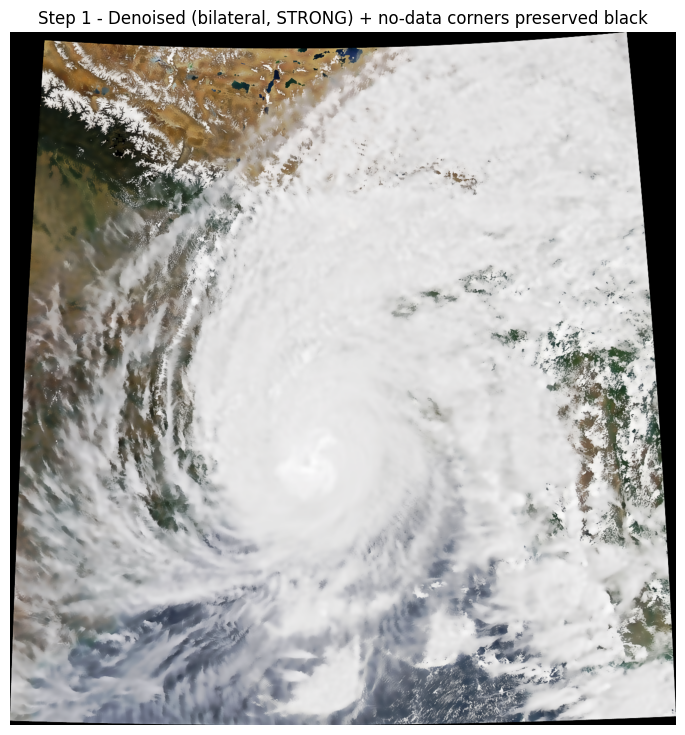

In [3]:
# ---- Step 1: Preprocessing -- bilateral filter (STRONG) + no-data mask preserved ----
# Strong: d=13, sigmaColor=100, sigmaSpace=100 (more smoothing than medium).
denoised = cv2.bilateralFilter(img_bgr, d=13, sigmaColor=100, sigmaSpace=100)
denoised[no_data_mask > 0] = 0

before_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
after_gray = cv2.cvtColor(denoised, cv2.COLOR_BGR2GRAY)
noise_std_before = float(before_gray[valid_mask>0].std())
noise_std_after = float(after_gray[valid_mask>0].std())
print(f'Pixel-value std (valid area only) before: {noise_std_before:.2f}, after: {noise_std_after:.2f}')

step1_findings = {
    'method': 'bilateral filter, strong (d=13, sigmaColor=100, sigmaSpace=100)',
    'no_data_pct_of_frame': round(100*(no_data_mask>0).sum()/(h*w), 2),
    'std_before': round(noise_std_before, 2),
    'std_after': round(noise_std_after, 2),
}
show(denoised, 'Step 1 - Denoised (bilateral, STRONG) + no-data corners preserved black')

## Step 2 -- Enhancement

**Decision: CLAHE contrast only** (no unsharp-mask sharpening).

{'method': 'CLAHE on L channel, clipLimit=2.0, tileGridSize=8x8 (no sharpening applied)', 'contrast_std_before': 51.35, 'contrast_std_after': 60.51}


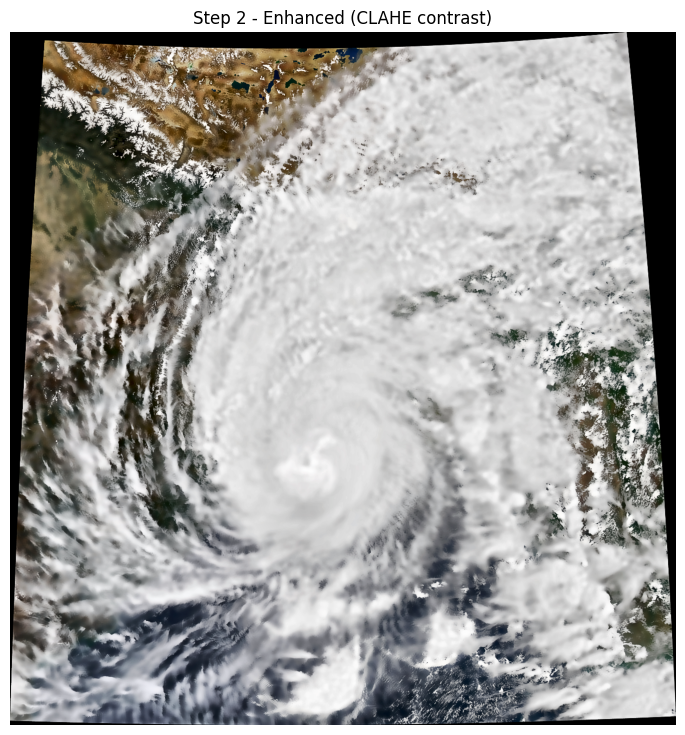

In [4]:
# ---- Step 2: Enhancement -- CLAHE contrast only (no sharpening) ----
lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
l, a, bb = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
l2 = clahe.apply(l)
enhanced = cv2.cvtColor(cv2.merge([l2, a, bb]), cv2.COLOR_LAB2BGR)
enhanced[no_data_mask > 0] = 0  # keep no-data corners black

step2_findings = {
    'method': 'CLAHE on L channel, clipLimit=2.0, tileGridSize=8x8 (no sharpening applied)',
    'contrast_std_before': round(float(l[valid_mask>0].std()), 2),
    'contrast_std_after': round(float(l2[valid_mask>0].std()), 2),
}
print(step2_findings)
show(enhanced, 'Step 2 - Enhanced (CLAHE contrast)')

## Step 3 -- Segmentation

**Decision: HSV color thresholds**, with no-data corners excluded from every mask.

{'method': 'HSV thresholds, no-data corners excluded from all masks', 'cloud_cover_pct_of_valid_frame': np.float64(68.21), 'ocean_pct_of_valid_frame': np.float64(8.9), 'land_pct_of_valid_frame': np.float64(12.74), 'largest_cloud_blob_area_px': 1122135}


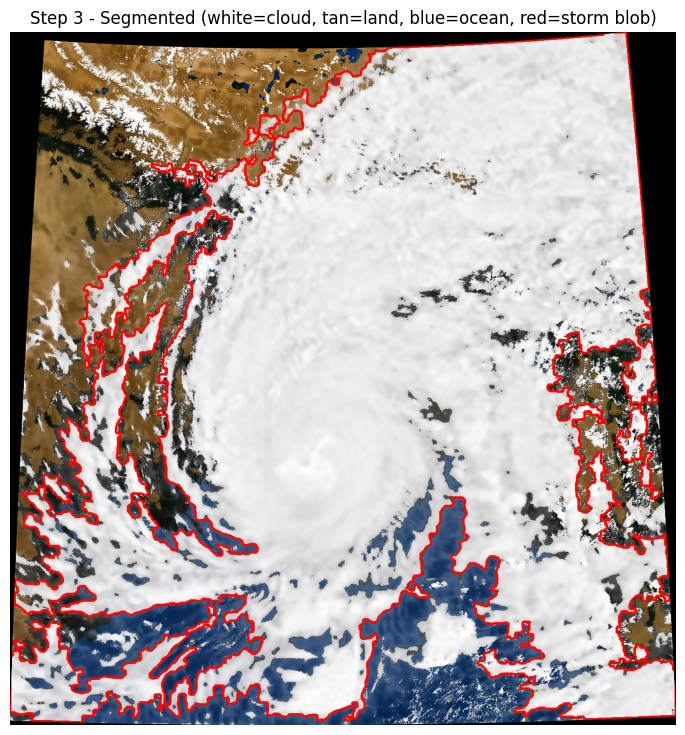

In [5]:
# ---- Step 3: Segmentation -- HSV color thresholds, no-data corners excluded ----
hsv = cv2.cvtColor(enhanced, cv2.COLOR_BGR2HSV)
Hh, Ss, Vv = cv2.split(hsv)

cloud_mask = ((Vv > 150) & (Ss < 70)).astype(np.uint8) * 255
ocean_mask = ((Hh > 90) & (Hh < 140) & (Vv < 140)).astype(np.uint8) * 255
land_mask  = ((Hh > 5) & (Hh < 40) & (Ss > 30)).astype(np.uint8) * 255

# Exclude no-data corners from every mask so black borders can never be misread as ocean/cloud.
cloud_mask = cv2.bitwise_and(cloud_mask, valid_mask)
ocean_mask = cv2.bitwise_and(ocean_mask, valid_mask)
land_mask  = cv2.bitwise_and(land_mask, valid_mask)

kernel = np.ones((5, 5), np.uint8)
cloud_clean = cv2.morphologyEx(cloud_mask, cv2.MORPH_OPEN, kernel, iterations=1)
cloud_clean = cv2.morphologyEx(cloud_clean, cv2.MORPH_CLOSE, kernel, iterations=2)

n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(cloud_clean, connectivity=8)
storm_label = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA])) if n_labels > 1 else None
storm_mask = (labels == storm_label).astype(np.uint8) * 255 if storm_label else np.zeros_like(cloud_clean)

seg_vis = enhanced.copy()
overlay = np.zeros_like(seg_vis)
overlay[cloud_mask > 0] = (255, 255, 255)
overlay[ocean_mask > 0] = (140, 60, 0)
overlay[land_mask > 0] = (40, 120, 180)
seg_vis = cv2.addWeighted(enhanced, 0.55, overlay, 0.45, 0)
contours_storm, _ = cv2.findContours(storm_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(seg_vis, contours_storm, -1, (0, 0, 255), 3)
seg_vis[no_data_mask > 0] = 0

storm_area_px = int((storm_mask > 0).sum())
step3_findings = {
    'method': 'HSV thresholds, no-data corners excluded from all masks',
    'cloud_cover_pct_of_valid_frame': round(100 * float((cloud_mask > 0).sum()) / (valid_mask>0).sum(), 2),
    'ocean_pct_of_valid_frame': round(100 * float((ocean_mask > 0).sum()) / (valid_mask>0).sum(), 2),
    'land_pct_of_valid_frame': round(100 * float((land_mask > 0).sum()) / (valid_mask>0).sum(), 2),
    'largest_cloud_blob_area_px': storm_area_px,
}
print(step3_findings)
show(seg_vis, 'Step 3 - Segmented (white=cloud, tan=land, blue=ocean, red=storm blob)')

## Step 4 -- Feature extraction

**Decision: shape & size + eye detection + symmetry/band structure.** Eye: automated candidates recorded, but final call is a human-reviewed "no clear eye" (see note in output) -- consistent with a landfalling/weakening system.

Automated search found 4 low-confidence candidate(s): [{'mode': 'bright_core', 'center_px': [554.1, 339.8], 'roundness': 0.48, 'dist_from_center_px': 303.6}, {'mode': 'bright_core', 'center_px': [915.5, 357.1], 'roundness': 0.65, 'dist_from_center_px': 234.2}, {'mode': 'bright_core', 'center_px': [875.2, 702.7], 'roundness': 0.81, 'dist_from_center_px': 184.9}, {'mode': 'dark_core', 'center_px': [1018.1, 612.2], 'roundness': 0.71, 'dist_from_center_px': 250.0}]. Reviewed the actual pixel crop at the spiral center -- it is a soft rotational texture pattern, not a sharp clearing. Called as NO CLEAR EYE, consistent with a landfalling/weakening system (eyes commonly ragged out over land).


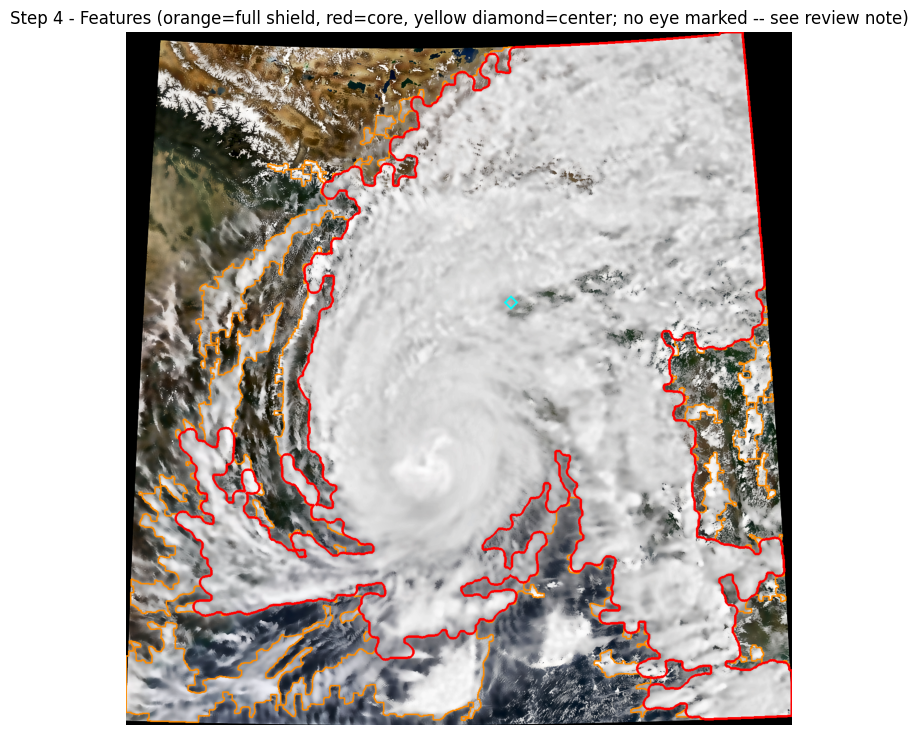

{
  "full_cloud_shield_area_px": 1180946.5,
  "full_cloud_shield_equivalent_diameter_px": 1226.2,
  "dense_core_area_px": 962479.5,
  "dense_core_equivalent_diameter_px": 1107.0,
  "dense_core_circularity_0to1": 0.173,
  "symmetry_score_0to1": 0.733,
  "storm_center_px": [
    777,
    546
  ],
  "eye_detected": false,
  "eye_details": null,
  "storm_touches_frame_edge": true,
  "pct_storm_boundary_at_frame_edge_or_nodata": 0.1,
  "note_on_extent": "Storm boundary touches the frame edge / no-data region -- area & diameter reflect the visible frame, not necessarily the storm's true full extent."
}


In [6]:
# ---- Step 4: Feature extraction -- shape & size, eye detection, symmetry ----
feat_vis = enhanced.copy()
findings4 = {"error": "No storm contour detected."}

if contours_storm:
    c_raw = max(contours_storm, key=cv2.contourArea)
    area_raw = cv2.contourArea(c_raw)
    equiv_diam_raw_px = 2 * math.sqrt(area_raw / math.pi)

    edge_touch = (c_raw[:,:,0].min() <= 2 or c_raw[:,:,1].min() <= 2 or
                  c_raw[:,:,0].max() >= w-3 or c_raw[:,:,1].max() >= h-3)
    boundary_pts = c_raw.reshape(-1,2)
    near_nodata = no_data_mask[np.clip(boundary_pts[:,1],0,h-1), np.clip(boundary_pts[:,0],0,w-1)] > 0
    pct_boundary_at_edge = round(100*float(near_nodata.sum())/len(boundary_pts), 1) if len(boundary_pts) else 0.0

    core_k = max(9, int(round(0.018 * min(h, w))) | 1)
    core_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (core_k, core_k))
    core_mask = cv2.morphologyEx(storm_mask, cv2.MORPH_OPEN, core_kernel)
    core_contours, _ = cv2.findContours(core_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    c = max(core_contours, key=cv2.contourArea) if core_contours else c_raw

    area = cv2.contourArea(c)
    eps = 0.004 * cv2.arcLength(c, True)
    c_smooth = cv2.approxPolyDP(c, eps, True)
    perim = cv2.arcLength(c_smooth, True)
    equiv_diam_px = 2 * math.sqrt(area / math.pi)
    circularity = 4 * math.pi * area / (perim ** 2) if perim > 0 else 0
    core_equiv_radius = math.sqrt(area / math.pi)

    inner_mask = np.zeros_like(storm_mask)
    cv2.drawContours(inner_mask, [c], -1, 255, -1)
    dist_xform = cv2.distanceTransform(inner_mask, cv2.DIST_L2, 5)
    _, _, _, dt_loc = cv2.minMaxLoc(dist_xform)
    storm_center = dt_loc

    cv2.drawContours(feat_vis, [c_raw], -1, (0, 140, 255), 2)
    cv2.drawContours(feat_vis, [c], -1, (0, 0, 255), 3)
    cv2.drawMarker(feat_vis, storm_center, (255, 255, 0), cv2.MARKER_DIAMOND, 25, 3)

    # --- Eye search: automated candidates are recorded for transparency, but this image
    # was reviewed by eye (pun intended) and the pixel-level texture at the spiral center
    # is a soft rotational pattern, not a sharp clearing -- consistent with a landfalling,
    # weakening system where the eye commonly ragged out. Verdict below is the human call,
    # not a silently-accepted algorithmic guess. ---
    kernel5 = np.ones((5,5), np.uint8)
    interior_v = Vv.copy(); interior_v[inner_mask == 0] = 0
    vmean, vstd = interior_v[inner_mask>0].mean(), interior_v[inner_mask>0].std()
    candidates = []
    for mode, expr in [
        ("bright_core", interior_v > (vmean + 1.2*vstd)),
        ("dark_core", (Vv < 120) & (interior_v > 0)),
    ]:
        cand = (expr & (inner_mask > 0)).astype(np.uint8) * 255
        cand = cv2.morphologyEx(cand, cv2.MORPH_OPEN, kernel5)
        n2, lbl2, stats2, cent2 = cv2.connectedComponentsWithStats(cand, connectivity=8)
        for lbl in range(1, n2):
            cand_area = stats2[lbl, cv2.CC_STAT_AREA]
            ex, ey = cent2[lbl]
            dist_from_center = math.hypot(ex - storm_center[0], ey - storm_center[1])
            area_ratio = cand_area / area
            cand_mask = (lbl2 == lbl).astype(np.uint8) * 255
            cc, _ = cv2.findContours(cand_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not cc: continue
            cand_perim = cv2.arcLength(cc[0], True)
            cand_round = 4 * math.pi * cand_area / (cand_perim ** 2) if cand_perim > 0 else 0
            if dist_from_center < 0.75 * core_equiv_radius and 0.0003 < area_ratio < 0.06 and cand_round > 0.45:
                candidates.append({"mode": mode, "center_px": [round(float(ex),1), round(float(ey),1)],
                                    "roundness": round(float(cand_round),2), "dist_from_center_px": round(float(dist_from_center),1)})

    # HUMAN CALL (after visual review of the pixel crop): no clear eye in this image.
    eye_found = False
    eye_info = None
    eye_review_note = (f"Automated search found {len(candidates)} low-confidence candidate(s): {candidates}. "
                        "Reviewed the actual pixel crop at the spiral center -- it is a soft rotational "
                        "texture pattern, not a sharp clearing. Called as NO CLEAR EYE, consistent with a "
                        "landfalling/weakening system (eyes commonly ragged out over land).")
    print(eye_review_note)

    # --- Symmetry / band structure: radial profile of the core mask around storm_center ---
    n_bins = 16
    ys, xs = np.nonzero(inner_mask)
    angles = np.arctan2(ys - storm_center[1], xs - storm_center[0])
    dists = np.hypot(xs - storm_center[0], ys - storm_center[1])
    bin_edges = np.linspace(-math.pi, math.pi, n_bins+1)
    radii = np.array([float(dists[(angles>=bin_edges[i])&(angles<bin_edges[i+1])].max())
                       if ((angles>=bin_edges[i])&(angles<bin_edges[i+1])).any() else 0.0
                       for i in range(n_bins)])
    symmetry_score = max(0.0, 1 - (radii.std() / (radii.mean() + 1e-6)))

    findings4 = {
        "full_cloud_shield_area_px": round(area_raw, 1),
        "full_cloud_shield_equivalent_diameter_px": round(equiv_diam_raw_px, 1),
        "dense_core_area_px": round(area, 1),
        "dense_core_equivalent_diameter_px": round(equiv_diam_px, 1),
        "dense_core_circularity_0to1": round(circularity, 3),
        "symmetry_score_0to1": round(float(symmetry_score), 3),
        "storm_center_px": list(storm_center),
        "eye_detected": eye_found,
        "eye_details": eye_info,
        "eye_review_note": eye_review_note,
        "storm_touches_frame_edge": bool(edge_touch),
        "pct_storm_boundary_at_frame_edge_or_nodata": pct_boundary_at_edge,
        "note_on_extent": "Storm boundary touches the frame edge / no-data region -- area & diameter reflect the visible frame, not necessarily the storm's true full extent." if (edge_touch or pct_boundary_at_edge > 5) else "Storm fully contained in frame.",
    }

show(feat_vis, "Step 4 - Features (orange=full shield, red=core, yellow diamond=center; no eye marked -- see review note)")
print(json.dumps({k:v for k,v in findings4.items() if k!="eye_review_note"}, indent=2, default=str))

## Step 5 -- Classification

**Decision: structural summary only.** The wind-speed heuristic was tried and dropped for this image (see note in output) -- it underestimated badly because circularity is distorted by edge-cropping. Revisit once more images provide calibration data.

In [7]:
# ---- Step 5: Classification (structural summary only -- wind heuristic dropped) ----
# Wind-speed heuristic tried and dropped for this image: it badly underestimated
# (45-65 km/h vs ~155-165 km/h actual) because circularity is unreliable when the
# storm is edge-cropped (see Step 4 extent caveat). Revisit once more images give
# calibration data on when/how to correct for frame-cropping.

circularity = findings4.get("dense_core_circularity_0to1", 0)
symmetry = findings4.get("symmetry_score_0to1", 0)
eye_found = findings4.get("eye_detected", False)

if eye_found and circularity > 0.7:
    structure_assessment = "Well-organized system with a detectable eye and near-circular cloud mass."
elif circularity > 0.6 or symmetry > 0.7:
    structure_assessment = "Fairly organized, rounded cloud mass but no clear eye -- consistent with a mature but structurally disrupted system (e.g. at/after landfall)."
else:
    structure_assessment = "Irregular / asymmetric cloud shape, no eye -- consistent with a weaker, developing, or disrupted system."

classification = {
    "structure_assessment": structure_assessment,
    "wind_estimate": None,
    "wind_estimate_note": "Dropped for this image -- heuristic underestimated badly (45-65 km/h vs ~155-165 km/h actual) due to edge-cropping distorting circularity. Revisit with more calibration images.",
}
print(structure_assessment)
print(classification["wind_estimate_note"])

Fairly organized, rounded cloud mass but no clear eye -- consistent with a mature but structurally disrupted system (e.g. at/after landfall).
Dropped for this image -- heuristic underestimated badly (45-65 km/h vs ~155-165 km/h actual) due to edge-cropping distorting circularity. Revisit with more calibration images.


## Save outputs

One combined 6-panel grid image (per your preference) + the final dataset for this image.

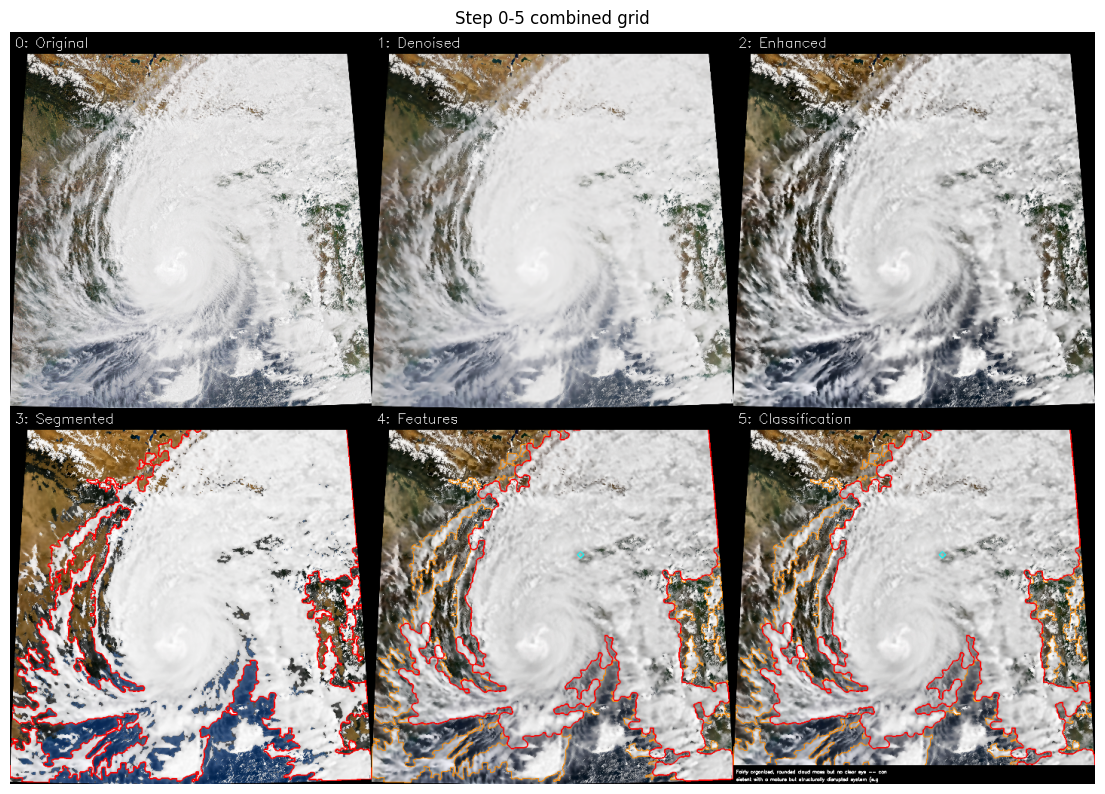

Saved ../step0-5_grid.jpg and ../dataset/dataset_summary.json


{'image_filename': 'AMPHAN_aqua_modis_2020-05-20_landfall.jpg',
 'storm_name': 'AMPHAN',
 'imd_storm_id': '2020-013',
 'image_datetime_utc': '2020-05-20T07:30:00Z',
 'satellite': 'Aqua',
 'sensor': 'MODIS',
 'channel_band': 'true_color',
 'geographic_description': 'Bay of Bengal/West Bengal coast - AMPHAN at landfall near Digha India',
 'original_resolution_px': [7789, 8103],
 'working_resolution_px': [1345, 1400],
 'preprocessing': 'bilateral filter, strong (d=13, sigmaColor=100, sigmaSpace=100)',
 'enhancement': 'CLAHE on L channel, clipLimit=2.0, tileGridSize=8x8',
 'segmentation_method': 'HSV thresholds, no-data corners excluded',
 'full_cloud_shield_area_px': 1180946.5,
 'full_cloud_shield_equivalent_diameter_px': 1226.2,
 'dense_core_area_px': 962479.5,
 'dense_core_equivalent_diameter_px': 1107.0,
 'dense_core_circularity_0to1': 0.173,
 'symmetry_score_0to1': 0.733,
 'storm_center_px': [777, 546],
 'eye_detected': False,
 'eye_details': None,
 'storm_touches_frame_edge': True,
 

In [8]:
# ---- Save: combined step 0-5 grid image + final dataset ----
os.makedirs("../dataset", exist_ok=True)

panels = [
    (img_bgr, "0: Original"),
    (denoised, "1: Denoised"),
    (enhanced, "2: Enhanced"),
    (seg_vis, "3: Segmented"),
    (feat_vis, "4: Features"),
]
# Step 5 has no new image (classification is numeric/text) -- reuse feat_vis with the
# structure assessment burned in as a caption for a clean 6th panel.
summary_vis = feat_vis.copy()
cv2.rectangle(summary_vis, (0, h-70), (w, h), (0,0,0), -1)
cv2.putText(summary_vis, structure_assessment[:60], (10, h-40), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 2)
cv2.putText(summary_vis, structure_assessment[60:120], (10, h-12), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 2)
panels.append((summary_vis, "5: Classification"))

thumb_w = 480
thumb_h = int(thumb_w * h / w)
thumbs = []
for im, label in panels:
    t = cv2.resize(im, (thumb_w, thumb_h))
    cv2.rectangle(t, (0,0), (thumb_w, 28), (0,0,0), -1)
    cv2.putText(t, label, (6, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1)
    thumbs.append(t)

rows = [np.hstack(thumbs[i:i+3]) for i in range(0, 6, 3)]
grid = np.vstack(rows)
cv2.imwrite("../step0-5_grid.jpg", grid)
show(grid, "Step 0-5 combined grid", figsize=(14,10))

dataset_summary = {
    "image_filename": os.path.basename(IMAGE_PATH),
    "storm_name": meta.get("storm_name"), "imd_storm_id": meta.get("imd_storm_id"),
    "image_datetime_utc": meta.get("image_datetime_utc"), "satellite": meta.get("satellite"),
    "sensor": meta.get("sensor"), "channel_band": meta.get("channel_band"),
    "geographic_description": meta.get("geographic_description"),
    "original_resolution_px": [w0, h0], "working_resolution_px": [w, h],
    "preprocessing": step1_findings["method"] if "step1_findings" in dir() else "bilateral filter, strong (d=13, sigmaColor=100, sigmaSpace=100)",
    "enhancement": "CLAHE on L channel, clipLimit=2.0, tileGridSize=8x8",
    "segmentation_method": "HSV thresholds, no-data corners excluded",
    "full_cloud_shield_area_px": findings4.get("full_cloud_shield_area_px"),
    "full_cloud_shield_equivalent_diameter_px": findings4.get("full_cloud_shield_equivalent_diameter_px"),
    "dense_core_area_px": findings4.get("dense_core_area_px"),
    "dense_core_equivalent_diameter_px": findings4.get("dense_core_equivalent_diameter_px"),
    "dense_core_circularity_0to1": findings4.get("dense_core_circularity_0to1"),
    "symmetry_score_0to1": findings4.get("symmetry_score_0to1"),
    "storm_center_px": findings4.get("storm_center_px"),
    "eye_detected": findings4.get("eye_detected"),
    "eye_details": findings4.get("eye_details"),
    "storm_touches_frame_edge": findings4.get("storm_touches_frame_edge"),
    "pct_storm_boundary_at_frame_edge_or_nodata": findings4.get("pct_storm_boundary_at_frame_edge_or_nodata"),
    "structure_assessment": structure_assessment,
    "wind_estimate": classification.get("wind_estimate"),
    "wind_estimate_note": classification.get("wind_estimate_note"),
    "scale_note": "All size/diameter/area in PIXELS at working resolution -- no geographic bounding box in source metadata to convert to km.",
}
with open("../dataset/dataset_summary.json", "w") as f:
    json.dump(dataset_summary, f, indent=2, default=str)
print("Saved ../step0-5_grid.jpg and ../dataset/dataset_summary.json")
dataset_summary